In [ ]:
#Install dependencies
!pip install transformers datasets seqeval torch -q
!pip install matplotlib
print('Dependencies installed')

✅ Dependencies installed


In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

#Imports and configuration
import json, random, gc, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from seqeval.metrics import (
    f1_score, precision_score, recall_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

#Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

#Hyperparameters
MAX_LEN      = 64    # Reduced from 128 due to T4 VRAM constraint
BATCH        = 4
ACCUM        = 2     # Effective batch size = BATCH * ACCUM = 8
EPOCHS       = 10
LR           = 5e-6  # More conservative than IndoBERT due to larger model
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
GRAD_CLIP    = 1.0

#Label set (BIO)
LABELS = ['O', 'B-SYM', 'I-SYM', 'B-DGN', 'I-DGN',
          'B-TMP', 'I-TMP', 'B-RF', 'I-RF']
L2I = {l: i for i, l in enumerate(LABELS)}
I2L = {i: l for l, i in L2I.items()}
NL  = len(LABELS)

#Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total')
if DEVICE.type == 'cpu':
    raise RuntimeError('❌ No GPU detected — connect to GPU before running XLM-RoBERTa')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'GPU memory: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total')
print(f'Labels ({NL}): {LABELS}')

Device: cuda
GPU: NVIDIA RTX A4000
Memory: 16.7 GB free / 16.9 GB total
Device: cuda
GPU memory: 16.7 GB free / 16.9 GB total
Labels (9): ['O', 'B-SYM', 'I-SYM', 'B-DGN', 'I-DGN', 'B-TMP', 'I-TMP', 'B-RF', 'I-RF']


In [ ]:
#Load data
import os
try:
    from google.colab import files
    print('Upload train_fixed.tsv, val_fixed.tsv, test_fixed.tsv:')
    uploaded = files.upload()
except ImportError:
    print('google.colab.files not available. Assuming files are in current directory.')
    uploaded = {}
    for filename in ['train_fixed.tsv', 'val_fixed.tsv', 'test_fixed.tsv']:
        if os.path.exists(filename):
            with open(filename, 'rb') as f:
                uploaded[filename] = f.read()
        else:
            print(f"Warning: {filename} not found locally. This may cause subsequent errors.")

def load_tsv(byte_content):
    """Parse CoNLL-style BIO TSV. Returns list of (tokens, labels) tuples."""
    sentences = []
    toks, labs = [], []
    for line in byte_content.decode('utf-8').splitlines():
        line = line.strip()
        if line == '':
            if toks:
                sentences.append((toks, labs))
            toks, labs = [], []
        else:
            parts = line.split('\t')
            if len(parts) == 2:
                toks.append(parts[0])
                labs.append(parts[1])
    if toks:
        sentences.append((toks, labs))
    return sentences

train_data = load_tsv(uploaded.get('train_fixed.tsv', b''))
val_data   = load_tsv(uploaded.get('val_fixed.tsv', b''))
test_data  = load_tsv(uploaded.get('test_fixed.tsv', b''))

print(f'\nLoaded — Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

#Sanity check: label set
all_labels_found = set()
for sents in [train_data, val_data, test_data]:
    for _, labs in sents:
        all_labels_found.update(labs)
unexpected = all_labels_found - set(LABELS)
print(f'Unexpected labels: {unexpected if unexpected else "None"}')

google.colab.files not available. Assuming files are in current directory.

Loaded — Train: 1211 | Val: 256 | Test: 275
Unexpected labels: None ✅


In [ ]:
#Dataset and tokenization
MODEL_NAME = 'cahya/xlm-roberta-large-indonesian-NER'
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def align_labels_with_tokens(sentences, tokenizer, max_len=MAX_LEN):
    """
    Tokenize word-split sentences and align BIO labels to subword tokens.
    Only the first subword token of each word receives the real label;
    continuation subword tokens and special tokens receive -100 (ignored in loss).

    Note on MAX_LEN=64: all queries have <= 59 word-level tokens. After XLM-RoBERTa
    subword tokenization, a small number of sentences may exceed 64 subword tokens
    and will be truncated. These are expected to be rare given the dataset's
    word-level length distribution.
    """
    all_input_ids, all_attention_masks, all_labels = [], [], []

    for tokens, labels in sentences:
        encoding = tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        word_ids     = encoding.word_ids(batch_index=0)
        aligned_labs = []
        prev_word_id = None
        for word_id in word_ids:
            if word_id is None:
                # Special token (<s>, </s>, <pad>)
                aligned_labs.append(-100)
            elif word_id != prev_word_id:
                # First subword of a word — use the real label
                lab = labels[word_id] if word_id < len(labels) else 'O'
                aligned_labs.append(L2I.get(lab, L2I['O']))
            else:
                # Continuation subword — ignore in loss
                aligned_labs.append(-100)
            prev_word_id = word_id

        all_input_ids.append(encoding['input_ids'].squeeze())
        all_attention_masks.append(encoding['attention_mask'].squeeze())
        all_labels.append(torch.tensor(aligned_labs))

    return all_input_ids, all_attention_masks, all_labels


class NERDataset(Dataset):
    def __init__(self, sentences, tokenizer, max_len=MAX_LEN):
        self.input_ids, self.attention_masks, self.labels = \
            align_labels_with_tokens(sentences, tokenizer, max_len)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_masks[idx],
            'labels':         self.labels[idx]
        }


train_dataset = NERDataset(train_data, tokenizer)
val_dataset   = NERDataset(val_data,   tokenizer)
test_dataset  = NERDataset(test_data,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')
print(f'Effective batch size: {BATCH} × {ACCUM} = {BATCH * ACCUM}')

Loading tokenizer: cahya/xlm-roberta-large-indonesian-NER
Train batches: 303 | Val batches: 64 | Test batches: 69
Effective batch size: 4 × 2 = 8


In [ ]:
#Model
print(f'Loading model: {MODEL_NAME}')
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NL,
    id2label=I2L,
    label2id=L2I,
    ignore_mismatched_sizes=True   # classifier head is re-initialized
).to(DEVICE)

# Required when using gradient checkpointing — disables KV cache
model.config.use_cache = False
model.gradient_checkpointing_enable()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

if torch.cuda.is_available():
    free, total_mem = torch.cuda.mem_get_info()
    print(f'GPU after model load: {free/1e9:.1f} GB free / {total_mem/1e9:.1f} GB total')

Loading model: cahya/xlm-roberta-large-indonesian-NER


Some weights of the model checkpoint at cahya/xlm-roberta-large-indonesian-NER were not used when initializing XLMRobertaForTokenClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at cahya/xlm-roberta-large-indonesian-NER and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([39]) in the checkpoint and torch.Size([9]) in the mode

Total parameters:     558,850,057
Trainable parameters: 558,850,057
GPU after model load: 14.5 GB free / 16.9 GB total


In [ ]:
#Optimizer and scheduler
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in model.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        'weight_decay': WEIGHT_DECAY
    },
    {
        'params': [p for n, p in model.named_parameters()
                   if     any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]
optimizer = AdamW(optimizer_grouped_parameters, lr=LR)

#Total optimizer steps = (complete accumulation cycles per epoch) × epochs
optimizer_steps_per_epoch = len(train_loader) // ACCUM
total_steps  = optimizer_steps_per_epoch * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
scaler = torch.cuda.amp.GradScaler()   # FP16 loss scaler

print(f'Train batches per epoch:      {len(train_loader)}')
print(f'Optimizer steps per epoch:    {optimizer_steps_per_epoch}')
print(f'Total optimizer steps:        {total_steps}')
print(f'Warmup steps:                 {warmup_steps}')

Train batches per epoch:      303
Optimizer steps per epoch:    151
Total optimizer steps:        1510
Warmup steps:                 151


In [ ]:
#Evaluation function
def evaluate(model, loader):
    """
    Span-level evaluation using seqeval.
    Uses FP16 autocast during inference, consistent with training.
    Returns macro F1, precision, recall, predicted sequences, gold sequences.
    """
    model.eval()
    all_preds, all_golds = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            with torch.cuda.amp.autocast(dtype=torch.float16):
                logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                ).logits

            preds = torch.argmax(logits, dim=-1)

            for pred_seq, gold_seq in zip(preds, labels):
                pred_tags, gold_tags = [], []
                for p, g in zip(pred_seq, gold_seq):
                    if g.item() == -100:
                        continue   # skip special/subword tokens
                    pred_tags.append(I2L[p.item()])
                    gold_tags.append(I2L[g.item()])
                all_preds.append(pred_tags)
                all_golds.append(gold_tags)

    macro_f1   = f1_score(all_golds,        all_preds, average='macro', zero_division=0)
    macro_prec = precision_score(all_golds,  all_preds, average='macro', zero_division=0)
    macro_rec  = recall_score(all_golds,    all_preds, average='macro', zero_division=0)

    return macro_f1, macro_prec, macro_rec, all_preds, all_golds

In [ ]:
#Training loop
best_val_f1  = 0.0
best_weights = None
history      = []

print('=' * 60)
print('MODEL 3: XLM-RoBERTa-large + Linear')
print(f'Epochs: {EPOCHS} | LR: {LR} | Batch: {BATCH} | Accum: {ACCUM} | MaxLen: {MAX_LEN}')
print('=' * 60)

for epoch in range(EPOCHS):
    #Training
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        #FP16 forward pass; loss divided by ACCUM for gradient scaling
        with torch.cuda.amp.autocast(dtype=torch.float16):
            loss = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            ).loss / ACCUM

        scaler.scale(loss).backward()
        running_loss += loss.item() * ACCUM   # log unscaled loss

        #Optimizer step every ACCUM batches
        if (step + 1) % ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % 40 == 0:
            torch.cuda.empty_cache()
            print(f'  Epoch {epoch+1} | Step {step+1}/{len(train_loader)} '
                  f'| Loss: {running_loss / (step+1):.4f}')

    avg_loss = running_loss / len(train_loader)

    #Validation
    val_f1, val_prec, val_rec, _, _ = evaluate(model, val_loader)

    print(f'\nEpoch {epoch+1}/{EPOCHS} '
          f'| Train Loss: {avg_loss:.4f} '
          f'| Val F1: {val_f1:.4f} '
          f'| Val P: {val_prec:.4f} '
          f'| Val R: {val_rec:.4f}')

    history.append({
        'epoch':    epoch + 1,
        'loss':     avg_loss,
        'val_f1':   val_f1,
        'val_prec': val_prec,
        'val_rec':  val_rec
    })

    #Save best checkpoint to CPU to save GPU memory
    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        best_weights = {k: v.clone().cpu() for k, v in model.state_dict().items()}
        print(f'New best val F1: {best_val_f1:.4f}')

    torch.cuda.empty_cache()
    print()

#Restore best checkpoint
if best_weights:
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_weights.items()})

print(f'Training complete. Best val F1: {best_val_f1:.4f}')

MODEL 3: XLM-RoBERTa-large + Linear
Epochs: 10 | LR: 5e-06 | Batch: 4 | Accum: 2 | MaxLen: 64
  Epoch 1 | Step 40/303 | Loss: 1.9935
  Epoch 1 | Step 80/303 | Loss: 1.7351
  Epoch 1 | Step 120/303 | Loss: 1.5131
  Epoch 1 | Step 160/303 | Loss: 1.3547
  Epoch 1 | Step 200/303 | Loss: 1.2360
  Epoch 1 | Step 240/303 | Loss: 1.1233
  Epoch 1 | Step 280/303 | Loss: 1.0290

Epoch 1/10 | Train Loss: 0.9816 | Val F1: 0.5076 | Val P: 0.5029 | Val R: 0.5359
  ✅ New best val F1: 0.5076

  Epoch 2 | Step 40/303 | Loss: 0.3671
  Epoch 2 | Step 80/303 | Loss: 0.3407
  Epoch 2 | Step 120/303 | Loss: 0.3240
  Epoch 2 | Step 160/303 | Loss: 0.3142
  Epoch 2 | Step 200/303 | Loss: 0.3052
  Epoch 2 | Step 240/303 | Loss: 0.2991
  Epoch 2 | Step 280/303 | Loss: 0.2937

Epoch 2/10 | Train Loss: 0.2878 | Val F1: 0.7281 | Val P: 0.6902 | Val R: 0.7745
  ✅ New best val F1: 0.7281

  Epoch 3 | Step 40/303 | Loss: 0.2279
  Epoch 3 | Step 80/303 | Loss: 0.2279
  Epoch 3 | Step 120/303 | Loss: 0.2199
  Epoch 3 

In [ ]:
#Test evaluation
test_f1, test_prec, test_rec, test_preds, test_golds = evaluate(model, test_loader)

print('MODEL 3 TEST RESULTS — XLM-RoBERTa-large + Linear')
print(f'Macro F1:        {test_f1:.4f}')
print(f'Macro Precision: {test_prec:.4f}')
print(f'Macro Recall:    {test_rec:.4f}')
print()
print(classification_report(test_golds, test_preds, zero_division=0))

#Collect per-entity scores
report_dict = classification_report(
    test_golds, test_preds, output_dict=True, zero_division=0
)
per_entity = {
    ent: {
        'prec': report_dict[ent]['precision'],
        'rec':  report_dict[ent]['recall'],
        'f1':   report_dict[ent]['f1-score']
    }
    for ent in ['DGN', 'RF', 'SYM', 'TMP']
}

results = {
    'model':      'XLM-RoBERTa-large+Linear',
    'overall':    {'f1': test_f1, 'prec': test_prec, 'rec': test_rec},
    'per_entity': per_entity,
    'history':    history
}

MODEL 3 TEST RESULTS — XLM-RoBERTa-large + Linear
Macro F1:        0.7735
Macro Precision: 0.7394
Macro Recall:    0.8125

              precision    recall  f1-score   support

         DGN       0.82      0.92      0.87       354
          RF       0.77      0.78      0.78       133
         SYM       0.69      0.74      0.72       435
         TMP       0.67      0.81      0.73       171

   micro avg       0.74      0.81      0.78      1093
   macro avg       0.74      0.81      0.77      1093
weighted avg       0.74      0.81      0.78      1093



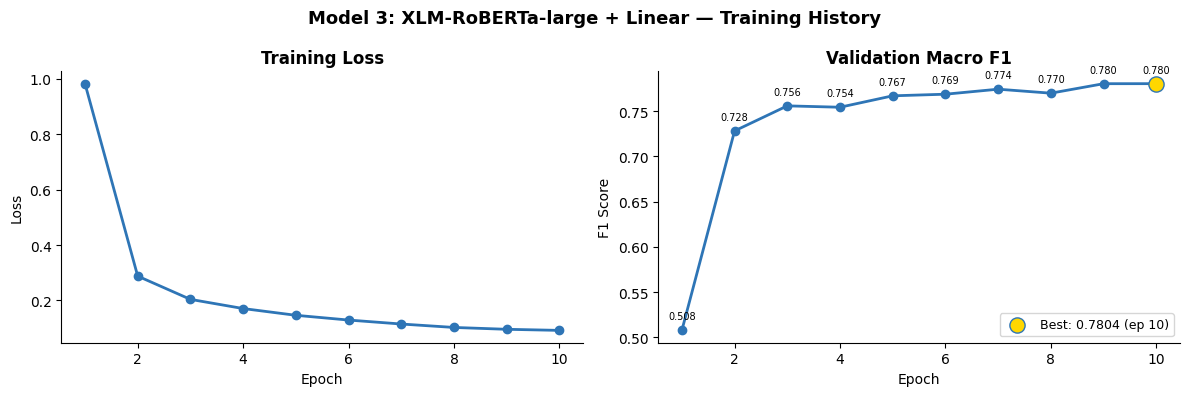

✅ Saved: m3_training_curves.png


In [ ]:
#Figure 1 Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Model 3: XLM-RoBERTa-large + Linear — Training History',
             fontsize=13, fontweight='bold')

epochs_x = [h['epoch'] for h in history]
COLOR = '#2E75B6'

#Loss
axes[0].plot(epochs_x, [h['loss']   for h in history],
             'o-', color=COLOR, lw=2, markersize=6)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

#Validation F1
axes[1].plot(epochs_x, [h['val_f1'] for h in history],
             'o-', color=COLOR, lw=2, markersize=6)
best_ep = max(history, key=lambda h: h['val_f1'])
axes[1].scatter([best_ep['epoch']], [best_ep['val_f1']],
                color='gold', s=120, zorder=5, edgecolors=COLOR,
                label=f"Best: {best_ep['val_f1']:.4f} (ep {best_ep['epoch']})")
axes[1].legend(fontsize=9)
for h in history:
    axes[1].annotate(f"{h['val_f1']:.3f}",
                     (h['epoch'], h['val_f1']),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=7)   # fontsize=7 for 10 epochs
axes[1].set_title('Validation Macro F1', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 Score')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('m3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m3_training_curves.png')

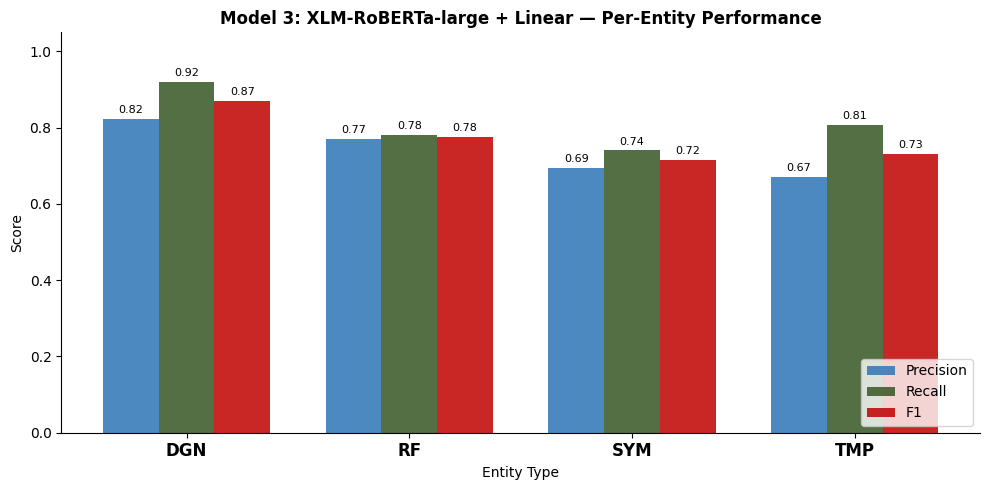

✅ Saved: m3_per_entity.png


In [ ]:
#Figure 2 Per-entity performance
ENTITIES = ['DGN', 'RF', 'SYM', 'TMP']
x = np.arange(len(ENTITIES))
w = 0.25

prec_vals = [per_entity[e]['prec'] for e in ENTITIES]
rec_vals  = [per_entity[e]['rec']  for e in ENTITIES]
f1_vals   = [per_entity[e]['f1']   for e in ENTITIES]

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w, prec_vals, w, label='Precision', color='#2E75B6', alpha=0.85)
b2 = ax.bar(x,     rec_vals,  w, label='Recall',    color='#375623', alpha=0.85)
b3 = ax.bar(x + w, f1_vals,   w, label='F1',        color='#C00000', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ENTITIES, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score'); ax.set_xlabel('Entity Type')
ax.set_title('Model 3: XLM-RoBERTa-large + Linear — Per-Entity Performance',
             fontweight='bold')
ax.legend(loc='lower right')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('m3_per_entity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m3_per_entity.png')

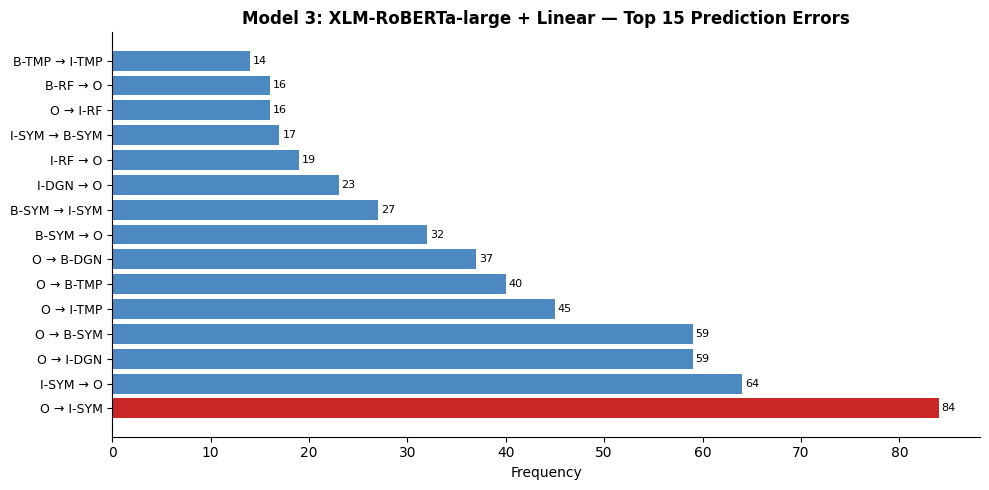

✅ Saved: m3_errors.png


In [ ]:
#Figure 3 Top prediction errors
error_counts = Counter()
for gold_seq, pred_seq in zip(test_golds, test_preds):
    for g, p in zip(gold_seq, pred_seq):
        if g != p:
            error_counts[(g, p)] += 1

top15 = error_counts.most_common(15)

if top15:
    labels_str = [f'{g} → {p}' for (g, p), _ in top15]
    counts     = [v for _, v in top15]

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#C00000' if v == max(counts) else '#2E75B6' for v in counts]
    bars   = ax.barh(range(len(top15)), counts, color=colors, alpha=0.85)

    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(labels_str, fontsize=9)
    ax.set_xlabel('Frequency')
    ax.set_title('Model 3: XLM-RoBERTa-large + Linear — Top 15 Prediction Errors',
                 fontweight='bold')

    for bar, val in zip(bars, counts):
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('m3_errors.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: m3_errors.png')
else:
    print('No errors found.')

In [ ]:
#Save to local server
import os, shutil, pickle, json

SAVE_DIR = '/home/misel/stroke_ner/outputs/v2/m3_xlm_roberta'
os.makedirs(SAVE_DIR, exist_ok=True)

#Save model and tokenizer (HuggingFace format)
model.save_pretrained(f'{SAVE_DIR}/model3_xlm_roberta')
tokenizer.save_pretrained(f'{SAVE_DIR}/model3_xlm_roberta')

#Save results
with open(f'{SAVE_DIR}/session3_results.pkl', 'wb') as f:
    pickle.dump(results, f)
with open(f'{SAVE_DIR}/session3_results.json', 'w') as f:
    json.dump({
        'model':      results['model'],
        'overall':    results['overall'],
        'per_entity': results['per_entity']
    }, f, indent=2)

#Save figures
for fname in ['m3_training_curves.png', 'm3_per_entity.png', 'm3_errors.png']:
    if os.path.exists(fname):
        shutil.copy(fname, f'{SAVE_DIR}/{fname}')

print('All outputs saved to Google Drive')
print(f'\nFINAL RESULTS — XLM-RoBERTa-large + Linear')
print(f'  Macro F1:        {test_f1:.4f}')
print(f'  Macro Precision: {test_prec:.4f}')
print(f'  Macro Recall:    {test_rec:.4f}')
print()
for e in ['DGN', 'RF', 'SYM', 'TMP']:
    pe = per_entity[e]
    print(f'  {e}: F1={pe["f1"]:.4f}  P={pe["prec"]:.4f}  R={pe["rec"]:.4f}')


✅ All outputs saved to Google Drive

FINAL RESULTS — XLM-RoBERTa-large + Linear
  Macro F1:        0.7735
  Macro Precision: 0.7394
  Macro Recall:    0.8125

  DGN: F1=0.8693  P=0.8232  R=0.9209
  RF: F1=0.7761  P=0.7704  R=0.7820
  SYM: F1=0.7164  P=0.6940  R=0.7402
  TMP: F1=0.7321  P=0.6699  R=0.8070
